模型准确率: 100.00%


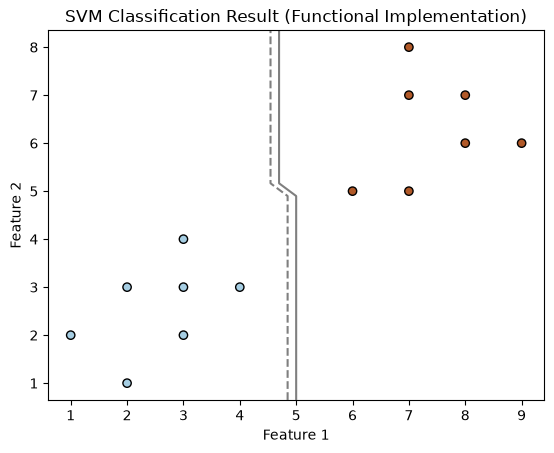

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_parameters(n_features):
    """初始化权重和偏置参数"""
    weights = np.zeros(n_features)
    bias = 0
    return weights, bias

def train_svm(X, y, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
    """训练SVM模型，返回训练后的权重和偏置"""
    n_samples, n_features = X.shape
    
    # 将标签转换为1和-1
    y_ = np.where(y <= 0, -1, 1)
    
    # 初始化参数
    weights, bias = initialize_parameters(n_features)
    
    # 梯度下降优化
    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            # 检查样本是否满足SVM条件
            condition = y_[idx] * (np.dot(x_i, weights) - bias) >= 1
            
            if condition:
                # 对于支持向量外的点，只更新正则化项
                weights -= learning_rate * (2 * lambda_param * weights)
            else:
                # 对于支持向量，更新整个损失函数的梯度
                weights -= learning_rate * (2 * lambda_param * weights - np.dot(x_i, y_[idx]))
                bias -= learning_rate * y_[idx]
    
    return weights, bias

def predict_svm(X, weights, bias):
    """使用训练好的参数进行预测"""
    linear_output = np.dot(X, weights) - bias
    return np.sign(linear_output)

def create_sample_data():
    """创建简单的二维分类数据集"""
    # 第一类数据点
    class1 = np.array([
        [1, 2], [2, 3], [3, 3], [2, 1], [3, 2],
        [4, 3], [3, 4]
    ])
    
    # 第二类数据点
    class2 = np.array([
        [6, 5], [7, 7], [8, 6], [7, 5], [8, 7],
        [9, 6], [7, 8]
    ])
    
    # 合并数据并创建标签
    X = np.vstack((class1, class2))
    y = np.hstack((np.zeros(len(class1)), np.ones(len(class2))))
    
    return X, y

def visualize_results(X, y, weights, bias):
    """可视化分类结果、决策边界和间隔"""
    # 绘制数据点
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k')
    
    # 获取当前坐标轴范围
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 创建网格用于绘制决策边界
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = predict_svm(xy, weights, bias).reshape(XX.shape)
    
    # 绘制决策边界和间隔
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    plt.title('SVM Classification Result (Functional Implementation)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

if __name__ == "__main__":
    # 创建数据集
    X, y = create_sample_data()
    
    # 训练SVM模型
    weights, bias = train_svm(X, y, learning_rate=0.001, lambda_param=0.01, n_iters=1000)
    
    # 预测并计算准确率
    predictions = predict_svm(X, weights, bias)
    # 将预测结果从1/-1转换为0/1以便与原始标签比较
    predictions = np.where(predictions == -1, 0, 1)
    accuracy = np.mean(predictions == y)
    print(f"模型准确率: {accuracy * 100:.2f}%")
    
    # 可视化结果
    visualize_results(X, y, weights, bias)
    

模型准确率: 100.00%


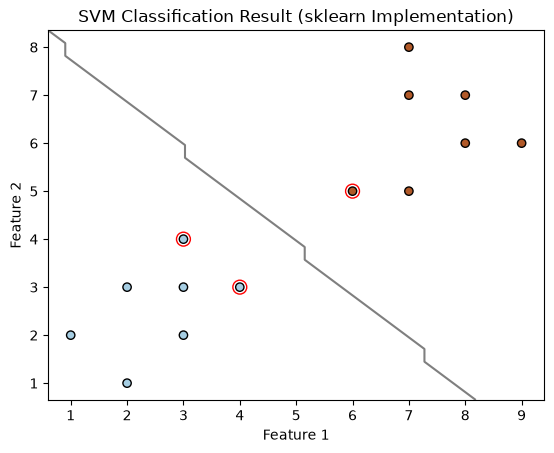

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def create_sample_data():
    """创建与手动实现相同的二维分类数据集"""
    # 第一类数据点
    class1 = np.array([
        [1, 2], [2, 3], [3, 3], [2, 1], [3, 2],
        [4, 3], [3, 4]
    ])
    
    # 第二类数据点
    class2 = np.array([
        [6, 5], [7, 7], [8, 6], [7, 5], [8, 7],
        [9, 6], [7, 8]
    ])
    
    # 合并数据并创建标签
    X = np.vstack((class1, class2))
    y = np.hstack((np.zeros(len(class1)), np.ones(len(class2))))
    
    return X, y

def visualize_results(X, y, model):
    """可视化分类结果、决策边界和间隔"""
    # 绘制数据点
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, edgecolors='k')
    
    # 获取当前坐标轴范围
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 创建网格用于绘制决策边界
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.predict(xy).reshape(XX.shape)
    
    # 绘制决策边界和间隔
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # 绘制支持向量
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='red')
    
    plt.title('SVM Classification Result (sklearn Implementation)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

if __name__ == "__main__":
    # 创建数据集
    X, y = create_sample_data()
    
    # 初始化并训练SVM模型
    # 使用线性核函数，C是正则化参数（与手动实现中的lambda_param作用相反）
    # C值越大，对错误分类的惩罚越重
    svm_model = SVC(kernel='linear', C=100)
    svm_model.fit(X, y)
    
    # 预测并计算准确率
    predictions = svm_model.predict(X)
    accuracy = accuracy_score(y, predictions)
    print(f"模型准确率: {accuracy * 100:.2f}%")
    
    # 可视化结果
    visualize_results(X, y, svm_model)